# Solving Ordinary Differential Equations Numerically

In any scientific field, it is important to learn how to solve all kinds of ordinary differential equations numerically and analytically. An **ordinary differential equation (ODE)** is an equation involving a single-variable function and its derivatives, and the solution is given as a function that satisfies the given differential equation. 

When analytical solutions are too difficult or impossible to find, we rely on **numerical methods** (typically iterative methods) to approximate the solution. This notebook covers three fundamental single-step methods for solving Initial Value Problems (IVPs) of the form:

$$\dot{y} = f(t, y), \quad y(t_0) = y_0$$

---

## 1. Euler's Method

Euler's Method is the most basic, first-order numerical procedure for solving ODEs. It uses the tangent line slope, $\dot{y}_i$, at the current point $(t_i, y_i)$ to step forward to the next point $(t_{i+1}, y_{i+1})$ over a small step size $h$.

### Mathematical Formula
$$y_{i+1} = y_i + h \cdot f(t_i, y_i)$$
$$t_{i+1} = t_i + h$$

### Error Characteristics
* **Local Truncation Error:** $\mathcal{O}(h^2)$
* **Global Truncation Error:** $\mathcal{O}(h)$ (First-order accuracy)

---

## 2. Modified Euler's Method (Heun's Method)

Heun's Method improves upon Euler's Method by using a **predictor-corrector** approach. Instead of relying solely on the initial derivative $\dot{y}_i$ at the beginning of the interval, it predicts the next point, calculates the derivative at that predicted point, and averages the two.

### Mathematical Formula
1. **Predictor Step (Standard Euler):**
   $$y_{i+1}^* = y_i + h \cdot f(t_i, y_i)$$

2. **Corrector Step (Averaged Slopes):**
   $$y_{i+1} = y_i + \frac{h}{2} \left[ f(t_i, y_i) + f(t_{i+1}, y_{i+1}^*) \right]$$

### Error Characteristics
* **Local Truncation Error:** $\mathcal{O}(h^3)$
* **Global Truncation Error:** $\mathcal{O}(h^2)$ (Second-order accuracy)

---

## 3. Classical Fourth-Order Runge-Kutta Method (RK4)

The RK4 method is the workhorse of numerical ODE solvers. It achieves high accuracy by taking four separate derivative samples ($k_1, k_2, k_3, k_4$) across the interval, taking a weighted average to extrapolate the final value.

### Mathematical Formula
$$y_{i+1} = y_i + \frac{h}{6}(k_1 + 2k_2 + 2k_3 + k_4)$$

Where the intermediate derivative stages are:
* $k_1 = f(t_i, y_i)$
* $k_2 = f\left(t_i + \frac{h}{2}, y_i + \frac{h}{2}k_1\right)$
* $k_3 = f\left(t_i + \frac{h}{2}, y_i + \frac{h}{2}k_2\right)$
* $k_4 = f(t_i + h, y_i + hk_3)$

### Error Characteristics
* **Local Truncation Error:** $\mathcal{O}(h^5)$
* **Global Truncation Error:** $\mathcal{O}(h^4)$ (Fourth-order accuracy)

---

## Error Analysis & Convergence

To evaluate the performance of each method, we will execute an error analysis by:
1. Comparing the numerical results against a known **analytical (exact) solution**.
2. Calculating the **Global Absolute Error** at the final boundary point: $E = |y_{\text{exact}} - y_{\text{numerical}}|$.
3. Varying the step size $h$ to visually confirm how quickly each method converges to the true solution.


# Part 1: Euler's Method

Let's solve a rather simple model. Consider the **Logistic Growth** model, defined as:

$$\dot{P} = rP\left(1-\frac{P}{K}\right), \quad P(t_0) = P_0$$

Where:
* $P$ represents the population size.
* $r$ is the intrinsic growth rate.
* $K$ is the carrying capacity of the environment.
* $P_0$ is the initial population at time $t_0$.

It is easy to find a solution to this equation analytically. However, we want to find a **numerical** solution to this equation. Let's begin by using **Euler's Method**.

---

### Derivation of the Iterative Scheme

To approximate the continuous function $P(t)$ at discrete time intervals, we begin with a first-order **Taylor series expansion** of $P(t+h)$ centered around the current time $t$:

$$P(t + h) = P(t) + h \cdot \dot{P}(t) + \frac{h^2}{2!} \cdot \ddot{P}(\xi)$$

Where $h$ is a small step size, $\dot{P}(t)$ is the first derivative with respect to time, and the final term represents the remainder (truncation error) evaluated at some point $\xi \in [t, t+h]$. 

If the step size $h$ is chosen to be sufficiently small, the higher-order term involving $h^2$ becomes negligible. Dropping this term gives us a local linear approximation:

$$P(t + h) \approx P(t) + h \cdot \dot{P}(t)$$

To turn this into a usable computational algorithm, we discretize the timeline into distinct, equally spaced steps:
$$t_i = t_0 + i \cdot h, \quad \text{for } i = 0, 1, 2, \dots$$

Letting $P_i \approx P(t_i)$ represent our numerical approximation at step $i$, the continuous relationship updates to a discrete **difference equation**:

$$P_{i+1} = P_i + h \cdot \dot{P}_i$$

Now, we substitute our specific physics/biological model definition, $\dot{P} = f(t, P) = rP\left(1-\frac{P}{K}\right)$, into the scheme:

$$P_{i+1} = P_i + h \cdot \left[ rP_i\left(1-\frac{P_i}{K}\right) \right]$$

This iterative formula allows us to step forward progressively from the initial state $P_0$ to discover the population curve over time.

### Derivation of the Exact Analytical Solution

To perform a rigorous error analysis on our numerical methods, we must compare our approximations against the exact analytical solution. We find this by solving the Logistic Growth ODE using the method of **separation of variables**.

Given the differential equation:
$$\dot{P} = rP\left(1 - \frac{P}{K}\right)$$

We can rewrite the right-hand side with a common denominator:
$$\dot{P} = \frac{r}{K} P (K - P)$$

Separating the variables $P$ and $t$ yields:
$$\frac{1}{P(K - P)} dP = \frac{r}{K} dt$$

To integrate the left side, we apply **partial fraction decomposition**:
$$\frac{1}{P(K - P)} = \frac{A}{P} + \frac{B}{K - P}$$

Multiplying both sides by $P(K - P)$ gives:
$$1 = A(K - P) + BP$$

* Setting $P = 0$ gives $1 = AK \implies A = \frac{1}{K}$.
* Setting $P = K$ gives $1 = BK \implies B = \frac{1}{K}$.

Substituting these back into our separated equation:
$$\left( \frac{1}{K \cdot P} + \frac{1}{K(K - P)} \right) dP = \frac{r}{K} dt$$

Multiply the entire equation by $K$ to simplify:
$$\left( \frac{1}{P} + \frac{1}{K - P} \right) dP = r \, dt$$

Now, we integrate both sides:
$$\int \frac{1}{P} dP + \int \frac{1}{K - P} dP = \int r \, dt$$
$$\ln|P| - \ln|K - P| = rt + C$$

Using the quotient property of logarithms:
$$\ln\left| \frac{P}{K - P} \right| = rt + C$$

Exponentiating both sides to solve for the population ratio:
$$\frac{P}{K - P} = e^{rt + C} = C_1 e^{rt} \quad \text{where } C_1 = e^C$$

Applying the initial condition $P(0) = P_0$ at $t = 0$:
$$\frac{P_0}{K - P_0} = C_1 e^{0} \implies C_1 = \frac{P_0}{K - P_0}$$

Now, we isolate $P(t)$:
$$P = C_1 e^{rt}(K - P)$$
$$P + C_1 e^{rt}P = C_1 K e^{rt}$$
$$P(1 + C_1 e^{rt}) = C_1 K e^{rt}$$
$$P(t) = \frac{C_1 K e^{rt}}{1 + C_1 e^{rt}}$$

Divide the numerator and denominator by $C_1 e^{rt}$ to clean up the expression:
$$P(t) = \frac{K}{\frac{1}{C_1} e^{-rt} + 1}$$

Substituting $1/C_1 = \frac{K - P_0}{P_0} = \frac{K}{P_0} - 1$:
$$P(t) = \frac{K}{1 + \left(\frac{K - P_0}{P_0}\right)e^{-rt}}$$

This expression provides the exact, continuous population value at any given time $t$.

---

### Python Implementation

We will now code both the exact analytical solution and our derived Euler iterative scheme. This script sets up the simulation parameters, executes the calculation loops, and compares the final results.


<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Troy\AppData\Local\Temp\ipykernel_9948\390140313.py:13: SyntaxWarning: invalid escape sequence '\d'
  """Returns the time derivative \dot{P} for logistic growth."""


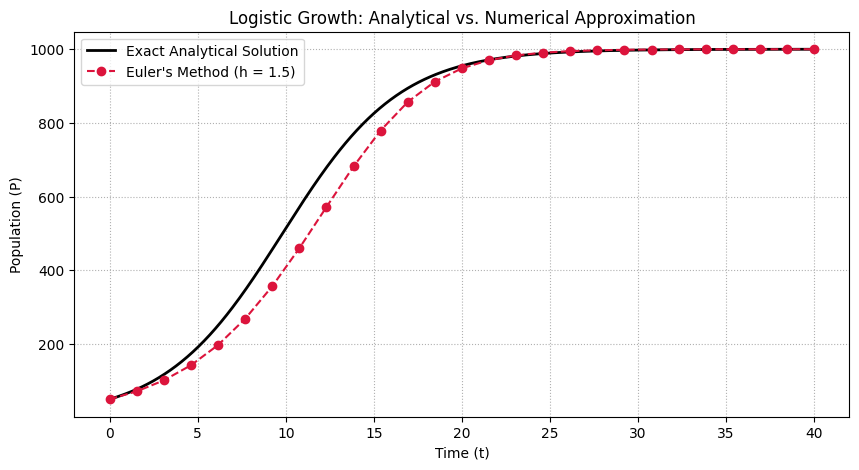

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define Model Parameters
r = 0.3       # Intrinsic growth rate
K = 1000      # Carrying capacity
P0 = 50       # Initial population size
t0, t_end = 0, 40
h = 1.5       # Step size 

# 2. Define the Functions
def logistic_rhs(t, P, r, K):
    """Returns the time derivative \dot{P} for logistic growth."""
    return r * P * (1.0 - P / K)

def exact_solution(t, P0, r, K):
    """Calculates the analytical value of P at time t."""
    return K / (1.0 + ((K - P0) / P0) * np.exp(-r * t))

# 3. Setup Grid and Arrays for Euler's Method
num_steps = int((t_end - t0) / h)
t_num = np.linspace(t0, t_end, num_steps + 1)
P_euler = np.zeros(num_steps + 1)
P_euler[0] = P0

# 4. Iterative Loop (Difference Equation)
for i in range(num_steps):
    P_dot = logistic_rhs(t_num[i], P_euler[i], r, K)
    P_euler[i+1] = P_euler[i] + h * P_dot

# 5. Generate Exact Data for Visualization
t_exact = np.linspace(t0, t_end, 500)
P_exact = exact_solution(t_exact, P0, r, K)

# 6. Plotting Results
plt.figure(figsize=(10, 5))
plt.plot(t_exact, P_exact, label='Exact Analytical Solution', color='black', lw=2)
plt.plot(t_num, P_euler, 'o--', label=f"Euler's Method (h = {h})", color='crimson')
plt.title('Logistic Growth: Analytical vs. Numerical Approximation')
plt.xlabel('Time (t)')
plt.ylabel('Population (P)')
plt.grid(True, linestyle=':')
plt.legend()
plt.show()